In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
# Processed datasets

fund_df = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

aum_df = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

sip_df = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")

category_df = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")

folio_df = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")

performance_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

transaction_df = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

holding_df = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

benchmark_df = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print(nav_df.head())

print(nav_df.shape)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
(46000, 3)


In [4]:
print(nav_df.columns)

print(aum_df.columns)

print(sip_df.columns)

print(category_df.columns)

print(transaction_df.columns)

print(folio_df.columns)

print(holding_df.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')
Index(['month', 'category', 'net_inflow_crore'], dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [5]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

# Highlight Bull Run (2023)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Correction (2024)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.show()

fig.write_image("../charts/nav_trend.png")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [ ]:

import plotly.io as pio

print(pio.renderers)
print("Current renderer:", pio.renderers.default)

Renderers configuration
-----------------------
    Default renderer: 'browser'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

Current renderer: browser


# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Objective

This notebook performs exploratory data analysis on the Mutual Fund Analytics dataset. It includes trend analysis, investor demographics, fund performance, and portfolio insights.

---

# Chart 1 - Daily NAV Trend Analysis

In [16]:
import plotly.express as px

# Convert date
nav_df["date"] = pd.to_datetime(nav_df["date"])

fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date":"Date",
        "nav":"Net Asset Value",
        "amfi_code":"AMFI Code"
    }
)

# Highlight Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.show(renderer="browser")

## Observation 1

Daily NAV values generally increased during 2023, indicating a strong market phase. The highlighted 2024 period shows comparatively slower movement, representing market correction.

In [10]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


# Chart 2 - AUM Growth Analysis

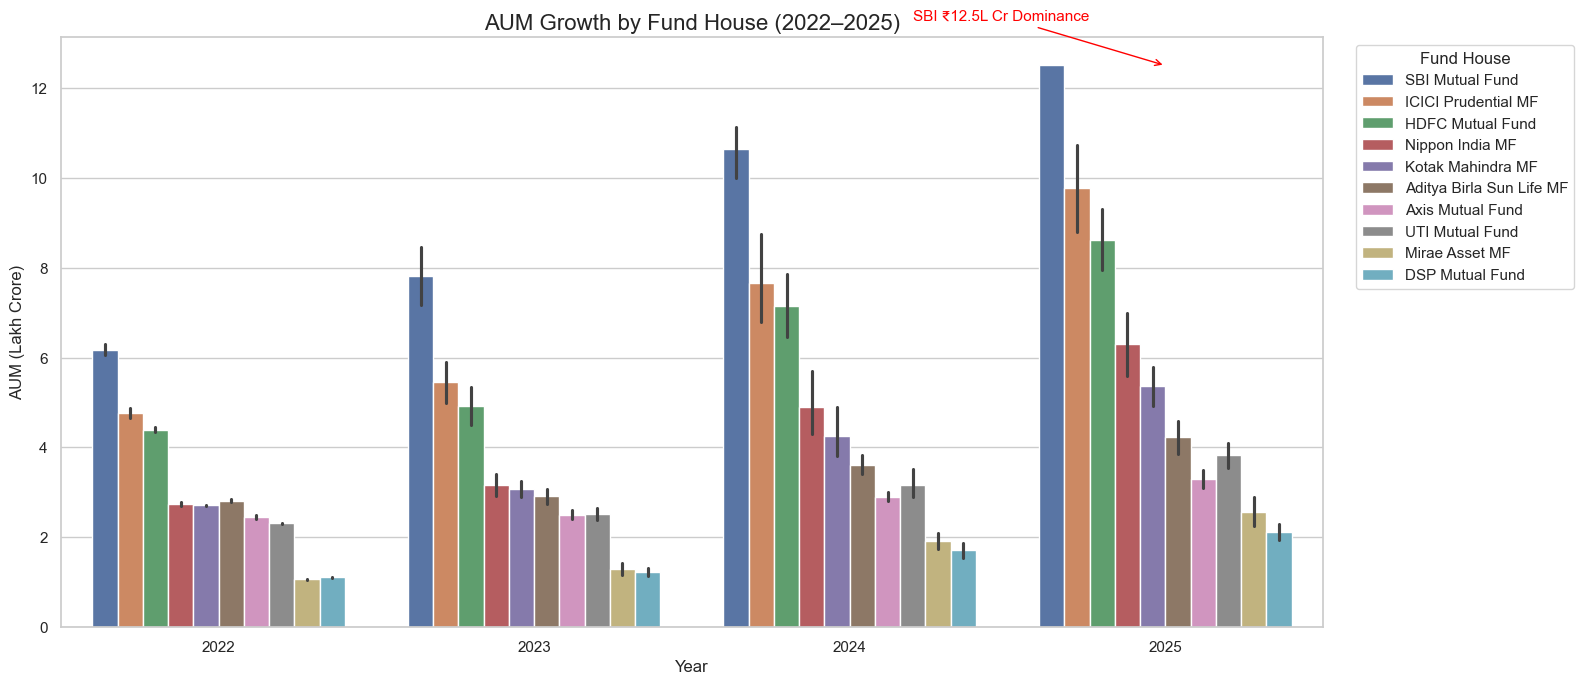

In [ ]:
#chart 2
import seaborn as sns
import matplotlib.pyplot as plt

# Convert date column
aum_df["date"] = pd.to_datetime(aum_df["date"])

# Extract year
aum_df["year"] = aum_df["date"].dt.year

# Create figure
plt.figure(figsize=(16,7))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)
plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

# Highlight SBI
plt.annotate(
    "SBI ₹12.5L Cr Dominance",
    xy=(3,12.5),
    xytext=(2.2,13.5),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=11,
    color="red"
)

plt.tight_layout()
plt.show()

## Observation 2

SBI Mutual Fund consistently maintained the highest Assets Under Management across all years, reaching approximately ₹12.5 lakh crore and outperforming other fund houses.

In [12]:
sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [13]:
print(sip_df.dtypes)

month                         object
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object


# Chart 3 - Monthly SIP Inflow Trend

In [ ]:
##chart 3
import plotly.express as px

# Convert month column
sip_df["month"] = pd.to_datetime(sip_df["month"])

# Create line chart
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Highlight Dec 2025
fig.add_annotation(
    x=pd.Timestamp("2025-12-01"),
    y=31002,
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-60
)

fig.show(renderer="browser")

## Observation 3

Monthly SIP inflows showed a consistent upward trend from 2022 to 2025, reaching an all-time high of ₹31,002 crore in December 2025.

# Chart 4 - Category Inflow Heatmap

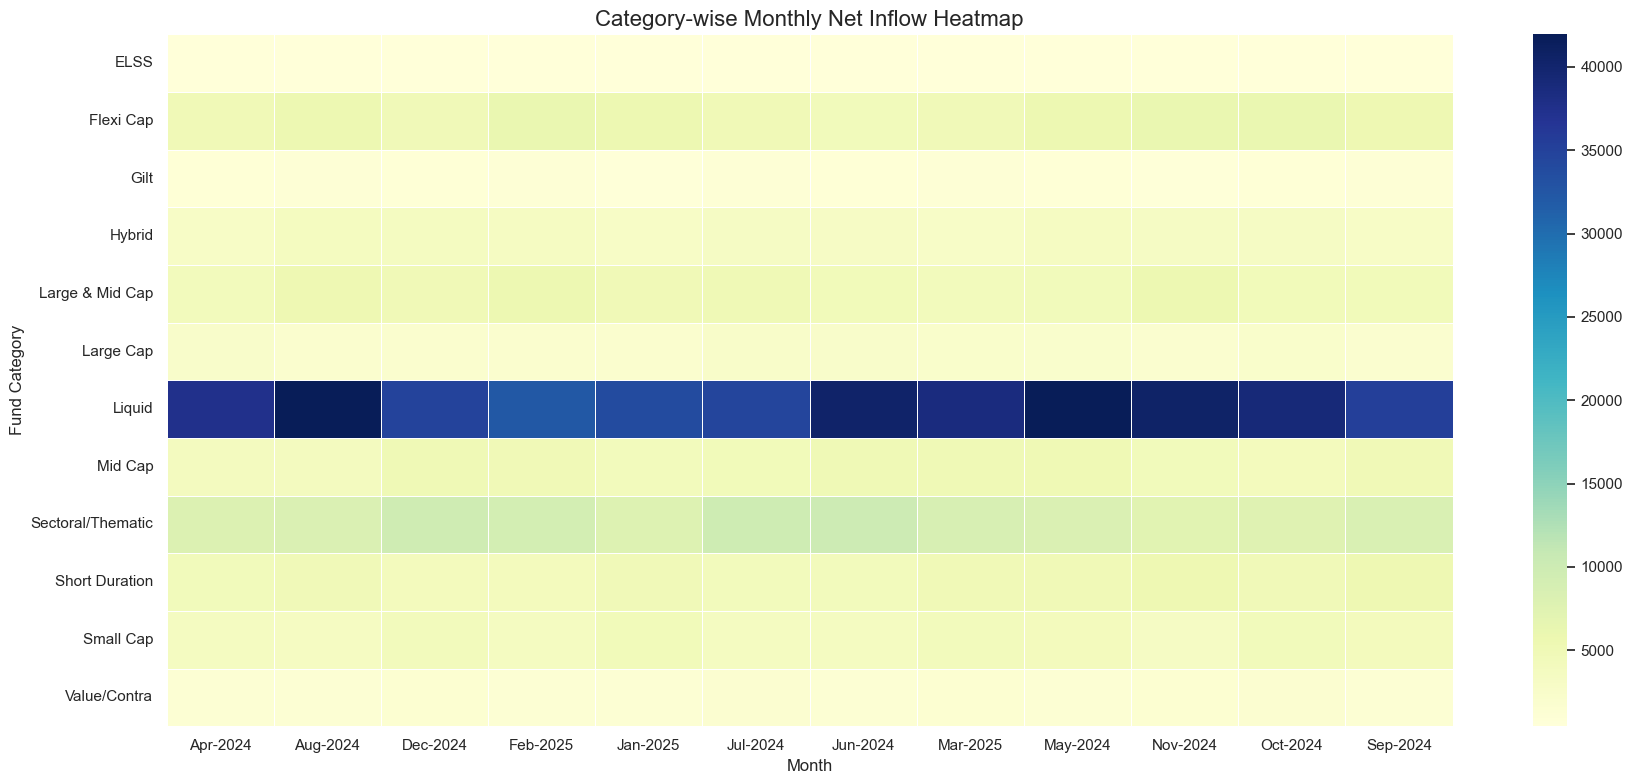

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert month to datetime
category_df["month"] = pd.to_datetime(category_df["month"])

# Format month labels
category_df["month_name"] = category_df["month"].dt.strftime("%b-%Y")

# Pivot table for heatmap
heatmap_data = category_df.pivot(
    index="category",
    columns="month_name",
    values="net_inflow_crore"
)

# Plot
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

### Observation 4

Net inflows varied considerably across fund categories over time. Equity-oriented categories generally recorded stronger inflows during bullish market periods, while other categories showed comparatively moderate investment activity.

# Chart 5 - Investor Demographics

Age Group Distribution Pie Chart

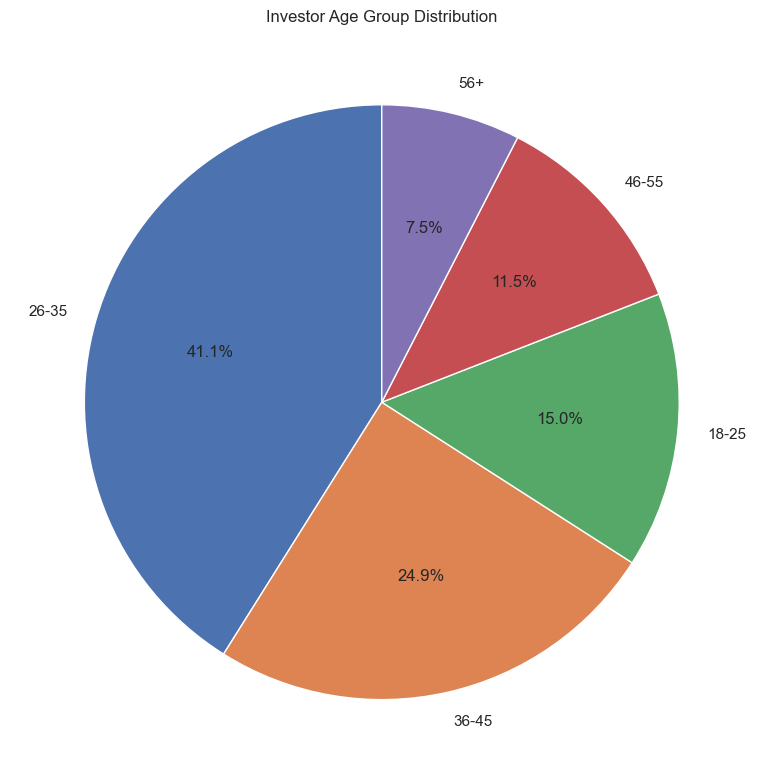

In [18]:
import matplotlib.pyplot as plt

age_counts = transaction_df["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.tight_layout()
plt.show()

### Observation 5

Most investors belong to the younger and middle-age groups, indicating strong participation from working professionals in mutual fund investments.

# Chart 6 SIP Amount by Age Group (Box Plot)

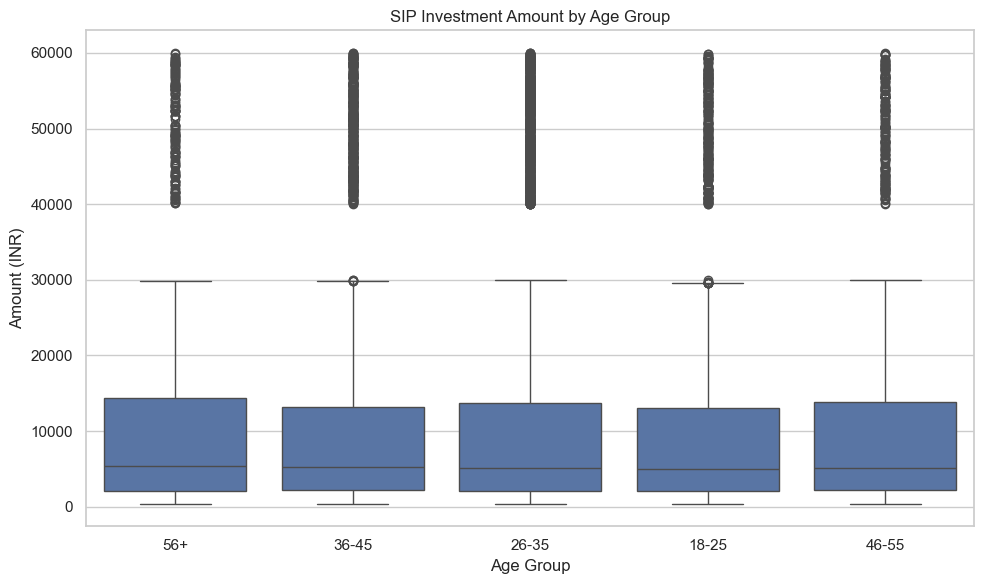

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sip_df = transaction_df[
    transaction_df["transaction_type"].str.upper() == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Investment Amount by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.tight_layout()
plt.show()

### Observation 6

SIP investment amounts vary across age groups, with several investors making significantly larger investments than the overall median.

# Chart 7 Gender Distribution

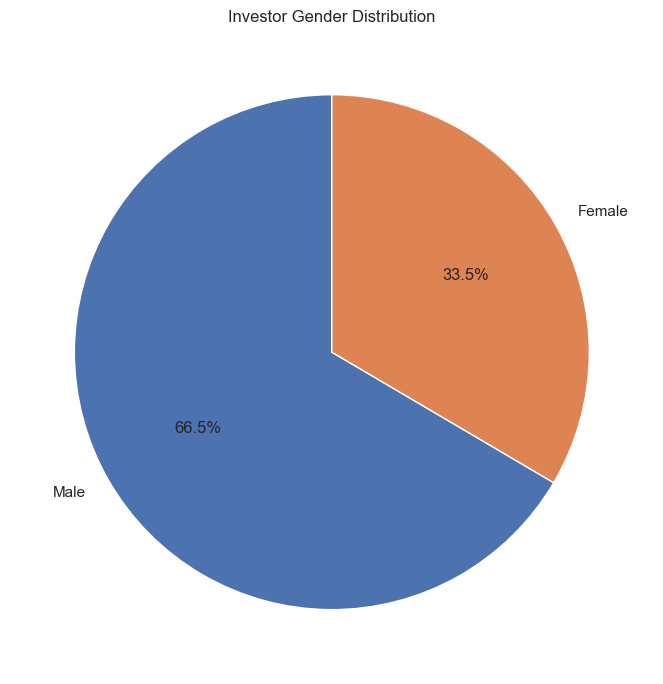

In [20]:
gender_counts = transaction_df["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.tight_layout()
plt.show()

### Observation 7

The investor base is distributed across genders, providing a balanced demographic view of mutual fund participation.

# Chart 8 - Geographic Distribution

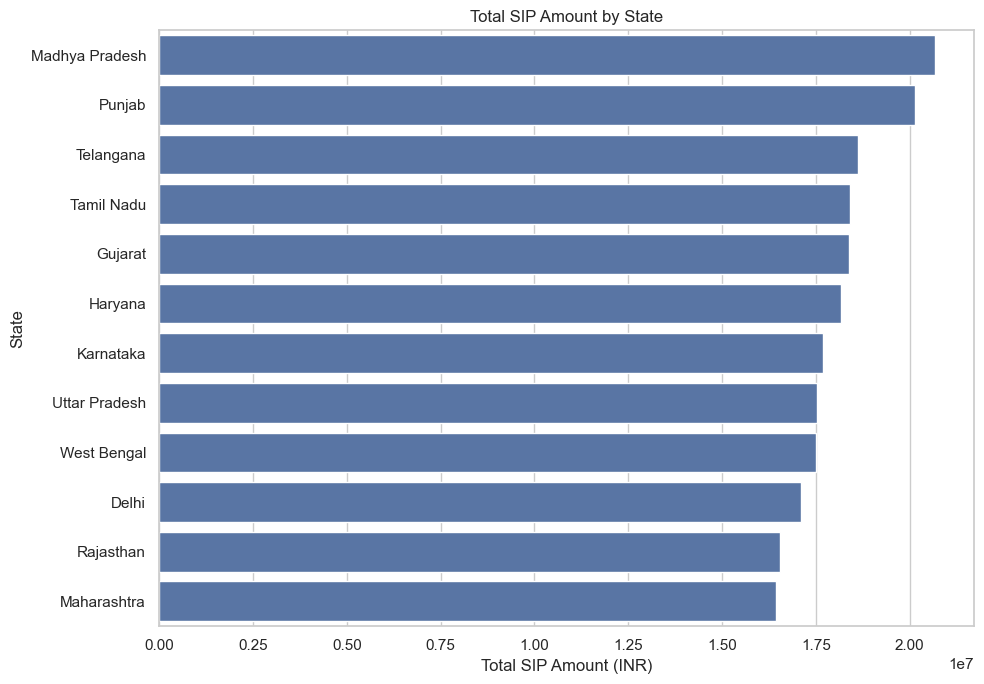

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

state_sip = (
    transaction_df[
        transaction_df["transaction_type"].str.upper() == "SIP"
    ]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,7))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Amount by State")

plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Observation 8

A few major states contribute a significant share of total SIP investments, while the remaining states contribute comparatively smaller volumes.

# Chart 9-T30 vs B30 City Tier Pie Chart

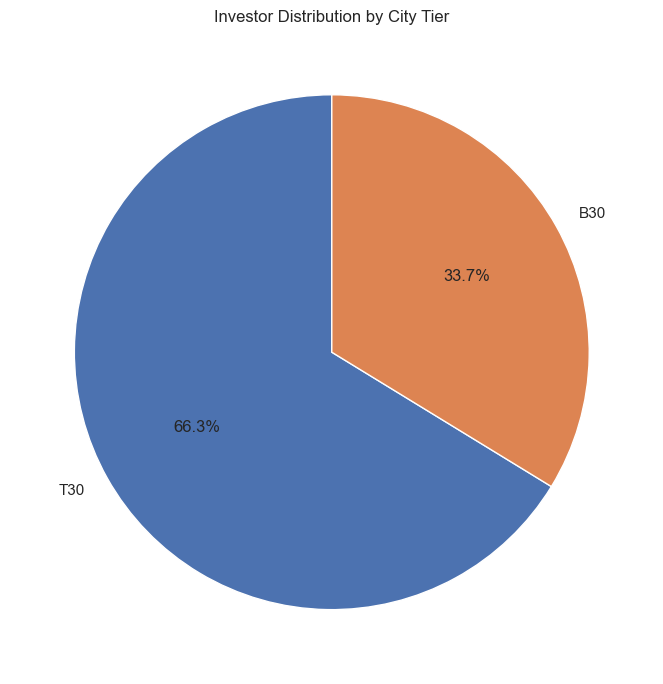

In [22]:
tier_counts = transaction_df["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by City Tier")

plt.tight_layout()
plt.show()

### Observation 9

Investor participation is concentrated across T30 and B30 cities, showing that mutual fund adoption extends beyond major metropolitan regions.

# Chart 10 - Folio Count Growth

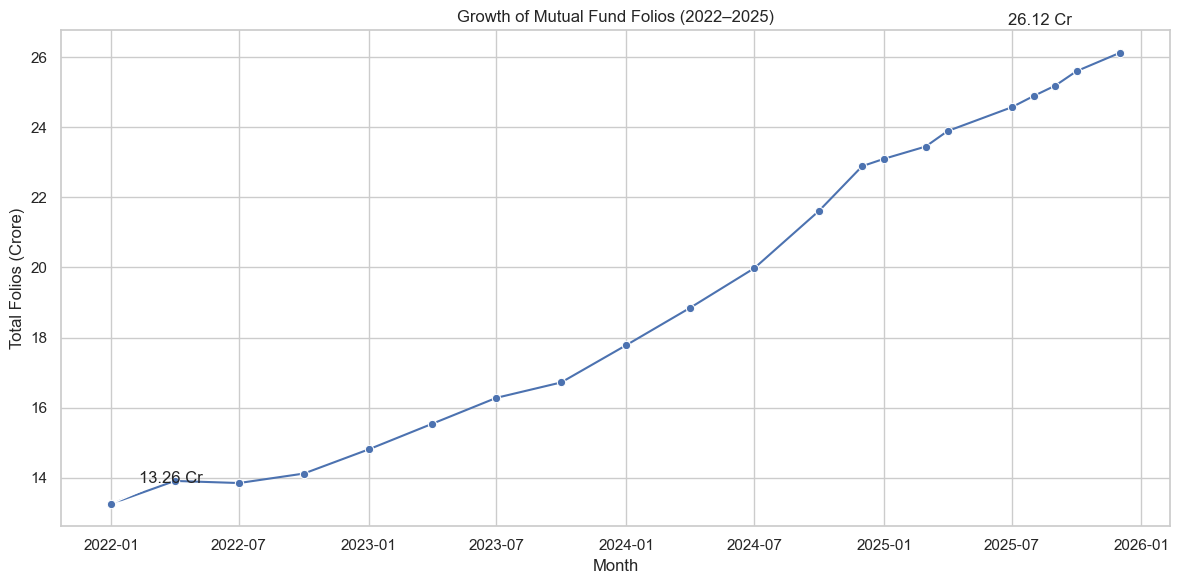

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert month column
folio_df["month"] = pd.to_datetime(folio_df["month"])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio_df,
    x="month",
    y="total_folios_crore",
    marker="o"
)

# Highlight first point
plt.annotate(
    "13.26 Cr",
    xy=(folio_df["month"].iloc[0], folio_df["total_folios_crore"].iloc[0]),
    xytext=(20,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Highlight last point
plt.annotate(
    "26.12 Cr",
    xy=(folio_df["month"].iloc[-1], folio_df["total_folios_crore"].iloc[-1]),
    xytext=(-80,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Growth of Mutual Fund Folios (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()
plt.show()

### Observation 10

The total number of mutual fund folios nearly doubled between January 2022 and December 2025, indicating strong and sustained growth in retail investor participation.

# Chart 11 - NAV Return Correlation Matrix

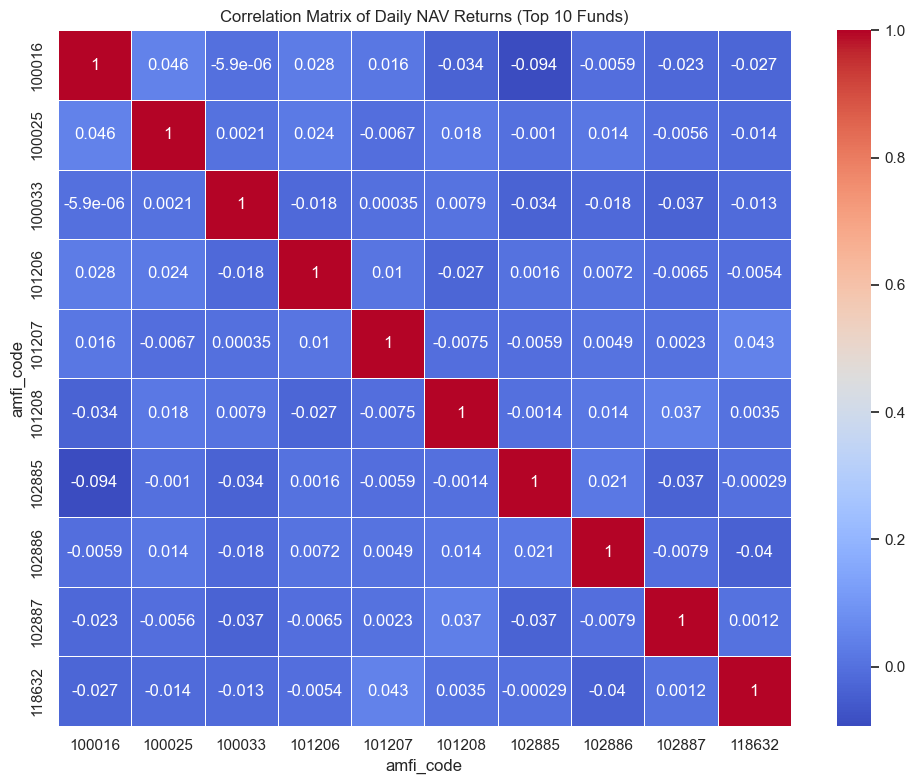

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select first 10 AMFI codes
top10_funds = nav_df["amfi_code"].unique()[:10]

# Filter data
corr_df = nav_df[nav_df["amfi_code"].isin(top10_funds)].copy()

# Pivot table
pivot_df = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily returns
returns = pivot_df.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns (Top 10 Funds)")

plt.tight_layout()
plt.show()

### Observation 11

Several mutual funds exhibit strong positive correlations in daily returns, indicating similar market movement patterns across selected schemes.

# Chart 12 - Sector Allocation Donut Chart

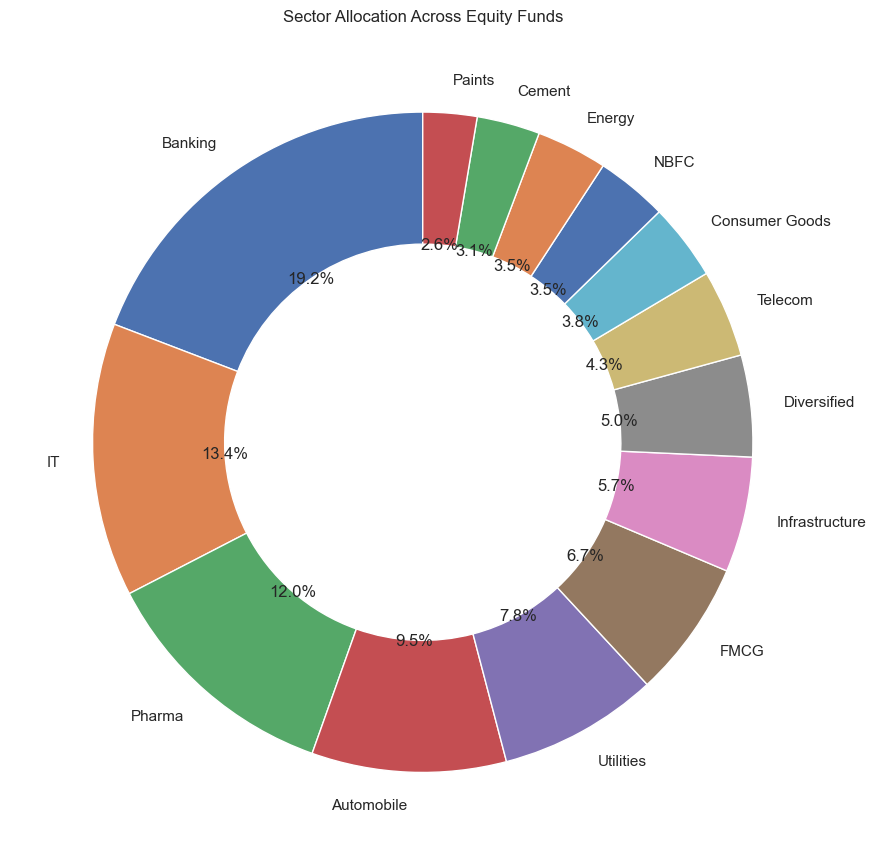

In [25]:
import matplotlib.pyplot as plt

# Aggregate sector weights
sector_weights = (
    holding_df
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,9))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()
plt.show()

### Observation 12

The portfolio allocation is diversified across multiple sectors, with a few sectors contributing the highest overall portfolio weight.

# Chart 13 - Transaction Type Distribution

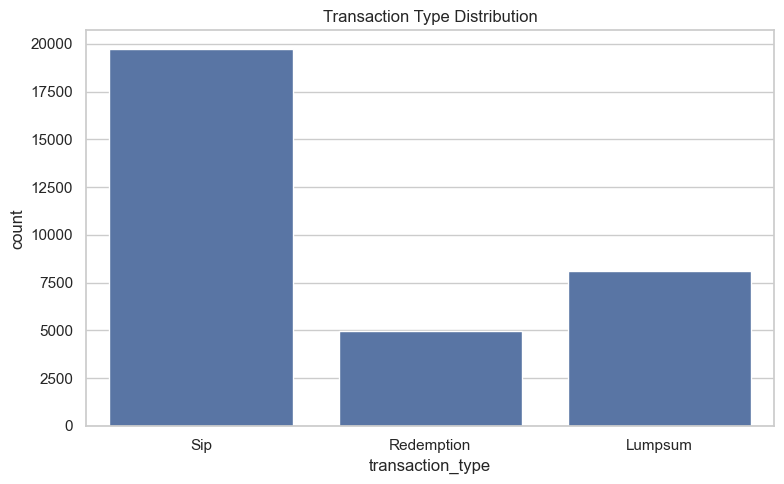

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transaction_df,
    x="transaction_type"
)

plt.title("Transaction Type Distribution")

plt.tight_layout()
plt.show()

### Observation 13

SIP transactions account for a significant portion of all mutual fund transactions compared to lumpsum investments and redemptions.

# Chart 14 - Payment Mode Distribution

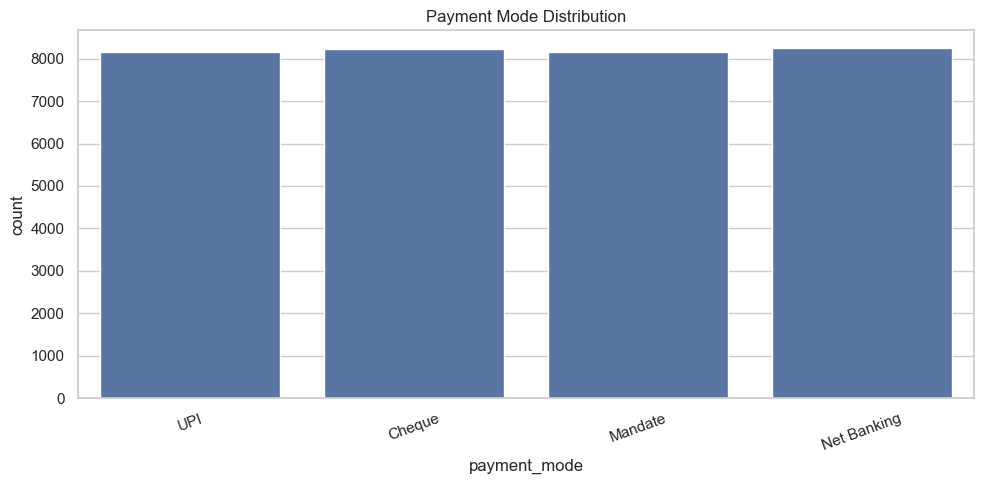

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=transaction_df,
    x="payment_mode"
)

plt.title("Payment Mode Distribution")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Observation 14

Digital payment methods are widely used for mutual fund investments, reflecting increasing adoption of online investment platforms.

# Chart 15 - Morningstar Rating Distribution

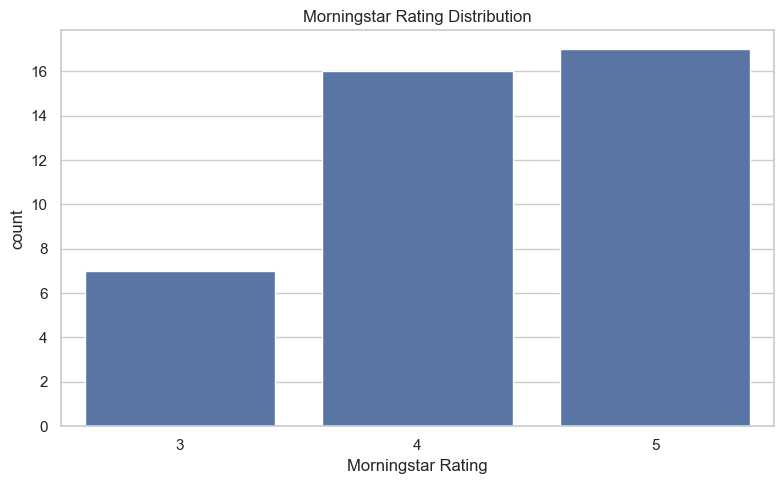

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance_df,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.xlabel("Morningstar Rating")

plt.tight_layout()
plt.show()

### Observation 15

Most mutual fund schemes are concentrated within the mid-to-high Morningstar rating categories, indicating generally strong fund performance.